# Customer Analytics. Visualizations

Recreating charts from the SQL analysis using matplotlib/seaborn.
Please run the visualizations in correct order! (from first to last)

In [3]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from db_connection import get_engine
from queries import MONTHLY_REVENUE_TRENDS, CUSTOMER_LTV, PRODUCT_ANALYSIS, NEW_VS_RETURNING, ACTIVE_VS_CHURNED, RFM_SEGMENTS, COHORT_ANALYSIS_RAW 

sns.set_style('whitegrid')
engine = get_engine()

## 1. Monthly revenue & customer trends

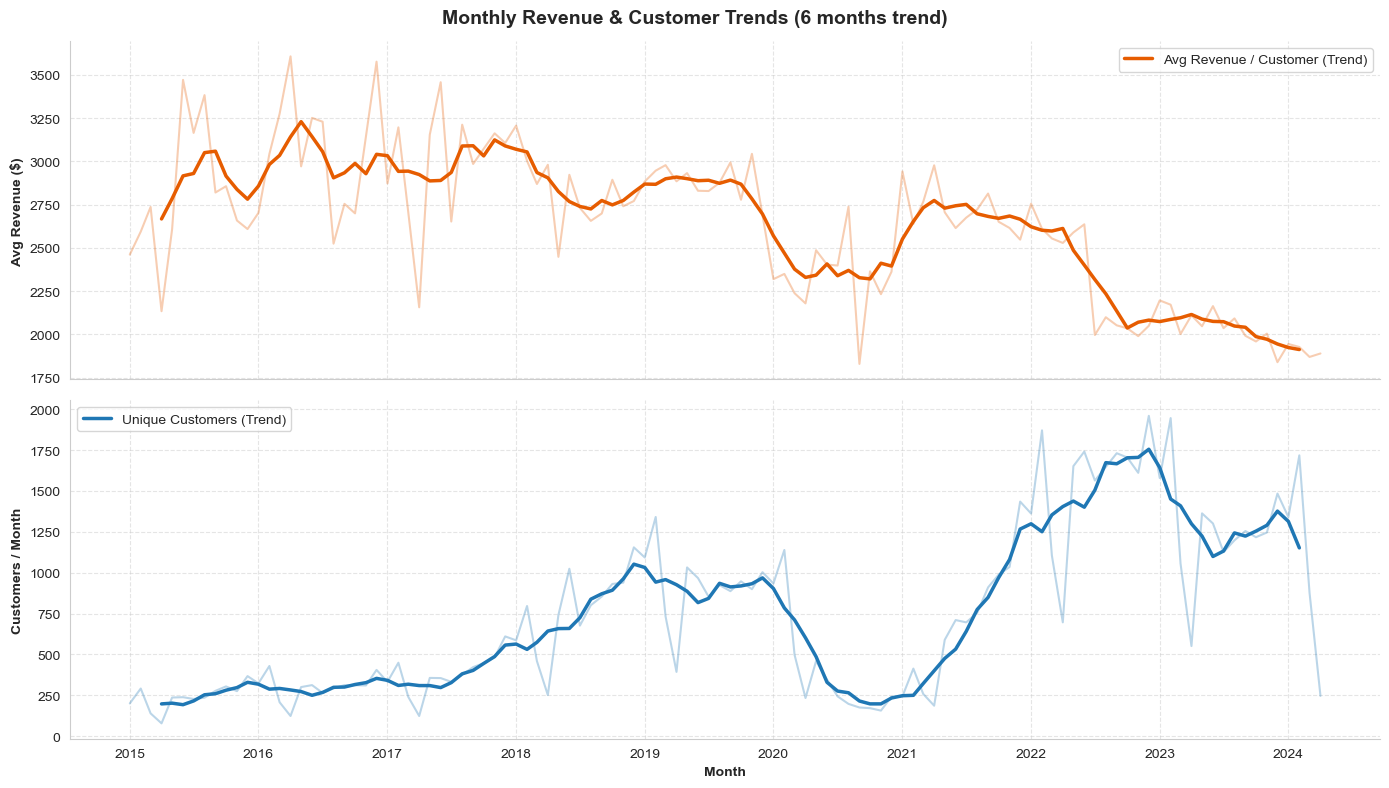

In [9]:

df_monthly = pd.read_sql(MONTHLY_REVENUE_TRENDS, engine)


df_monthly['avg_rev_smooth'] = df_monthly['avg_revenue_per_customer'].rolling(window=6, center=True).mean()
df_monthly['customers_smooth'] = df_monthly['total_number_of_customers'].rolling(window=6, center=True).mean()

color_orange = '#E65C00'
color_blue = '#1F77B4'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)



ax1.plot(df_monthly['month_of_year'], df_monthly['avg_revenue_per_customer'], color=color_orange, alpha=0.3)

ax1.plot(df_monthly['month_of_year'], df_monthly['avg_rev_smooth'], color=color_orange, linewidth=2.5, label='Avg Revenue / Customer (Trend)')
ax1.set_ylabel('Avg Revenue ($)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


ax2.plot(df_monthly['month_of_year'], df_monthly['total_number_of_customers'], color=color_blue, alpha=0.3)

ax2.plot(df_monthly['month_of_year'], df_monthly['customers_smooth'], color=color_blue, linewidth=2.5, label='Unique Customers (Trend)')
ax2.set_ylabel('Customers / Month', fontweight='bold')
ax2.set_xlabel('Month', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.suptitle('Monthly Revenue & Customer Trends (6 months trend)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../../images/monthly_revenue_trends.png', dpi=150) 
plt.show()

## 2. Raw vs rolling average revenue

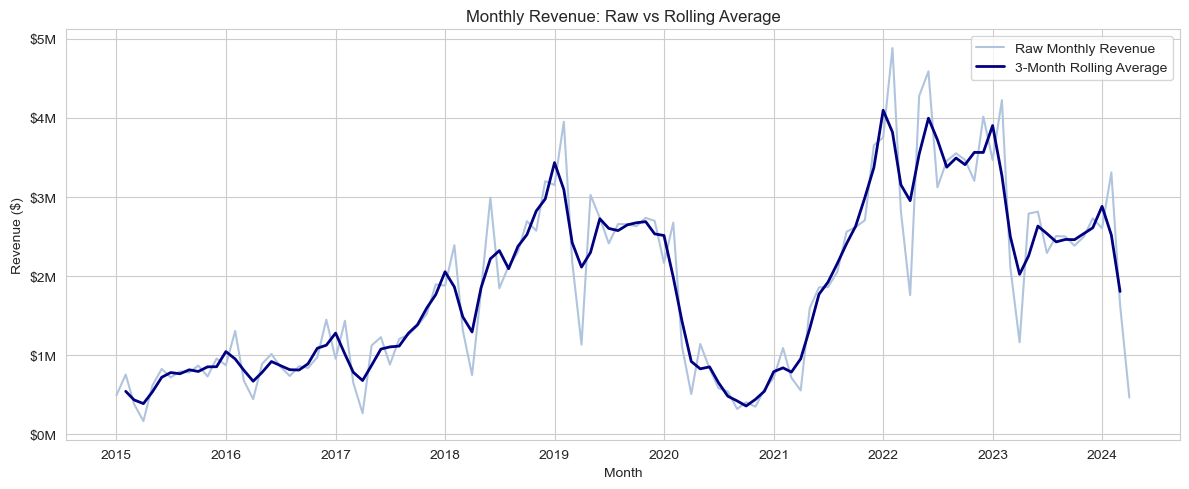

In [18]:
df_monthly['rolling_avg'] = df_monthly['total_revenue'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_monthly['month_of_year'], df_monthly['total_revenue'], color='lightsteelblue', label='Raw Monthly Revenue')
ax.plot(df_monthly['month_of_year'], df_monthly['rolling_avg'], color='navy', linewidth=2, label='3-Month Rolling Average')

ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Month')
ax.set_title('Monthly Revenue: Raw vs Rolling Average')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x/1e6:.0f}M"))
plt.tight_layout()
plt.savefig('../../images/raw_vs_rolling_average.png', dpi=150)
plt.show()

## 3. Revenue share by LTV segment

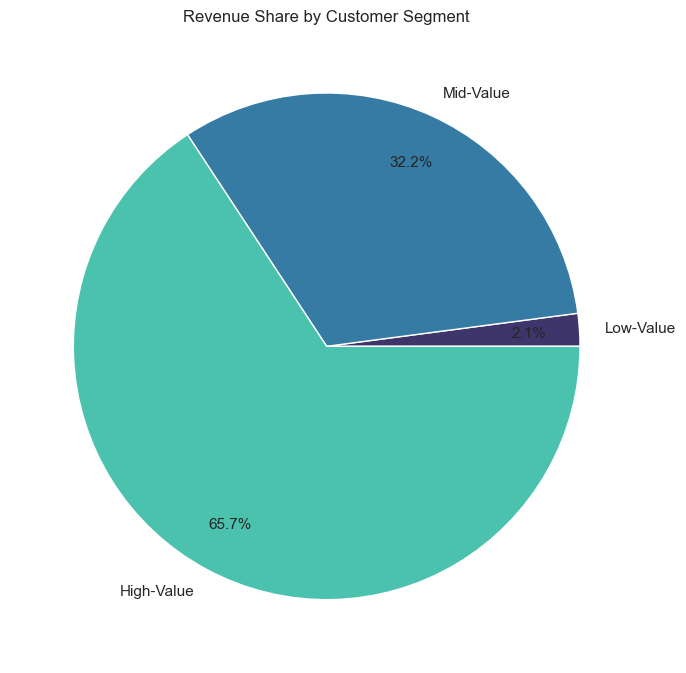

In [9]:
df_ltv = pd.read_sql(CUSTOMER_LTV, engine)

q1, q3 = df_ltv['total_ltv'].quantile([0.25, 0.75])

df_ltv['segment'] = pd.cut(
    df_ltv['total_ltv'],
    bins=[-np.inf, q1, q3, np.inf],
    labels=['Low-Value', 'Mid-Value', 'High-Value']
)

segment_revenue = df_ltv.groupby('segment', observed=True)['total_ltv'].sum()

colors = sns.color_palette('mako', n_colors=3)

fig, ax = plt.subplots(figsize=(7, 7))
segment_revenue.plot(
    kind='pie',
    ax=ax,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.8,
    textprops={'fontsize': 11},
    ylabel='',
    title='Revenue Share by Customer Segment'
)

plt.tight_layout()
plt.savefig('../../images/RevenueCustomerSegment.png', dpi=150)
plt.show()

## 4. Active vs Churned by cohort year

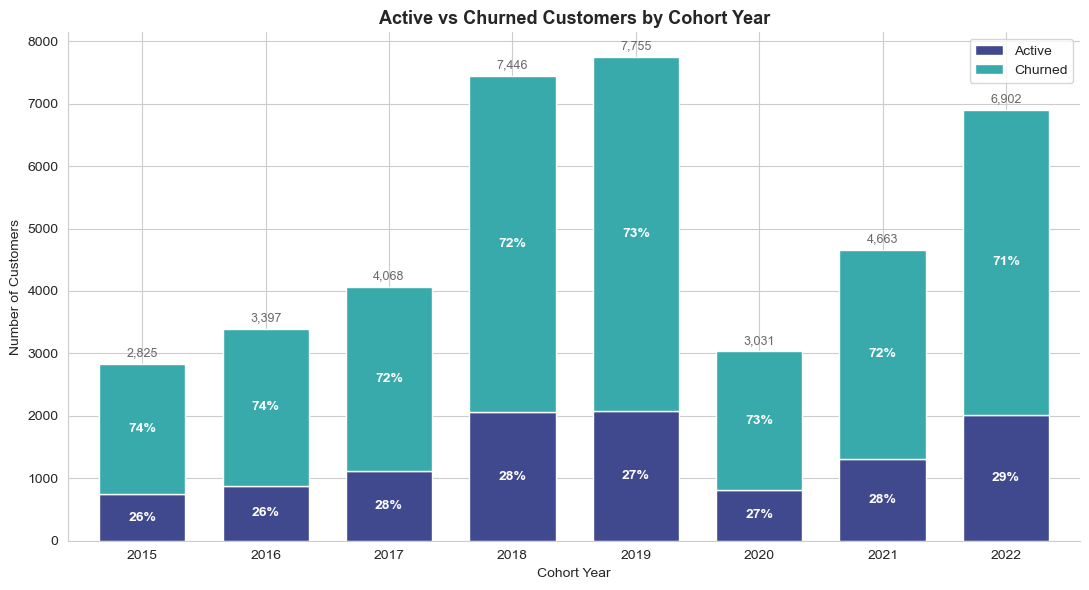

In [ ]:
df_churn = pd.read_sql(ACTIVE_VS_CHURNED, engine)
pivot = df_churn.pivot(index='cohort_year', columns='customer_status', values='num_customers').fillna(0)
totals = pivot.sum(axis=1)

pivot.index = pivot.index.astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette('mako', n_colors=2)

pivot[['Active', 'Churned']].plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.7)


for i, year in enumerate(pivot.index):
    cum = 0
    for status in ['Active', 'Churned']:
        value = pivot.loc[year, status]
        pct = value / totals[year]
        if pct > 0.03:  
            ax.text(i, cum + value / 2, f'{pct:.0%}', ha='center', va='center',
                     color='white', fontweight='bold', fontsize=10)
        cum += value
    ax.text(i, totals[year] + totals.max() * 0.01, f'{int(totals[year]):,}',
             ha='center', va='bottom', fontsize=9, color='dimgray')

ax.set_ylabel('Number of Customers')
ax.set_xlabel('Cohort Year')
ax.set_title('Active vs Churned Customers by Cohort Year', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
ax.legend(title='')
sns.despine()
plt.tight_layout()
plt.savefig('../../images/churn_by_cohort.png', dpi=150)
plt.show()

## 5. New vs returning customer revenue

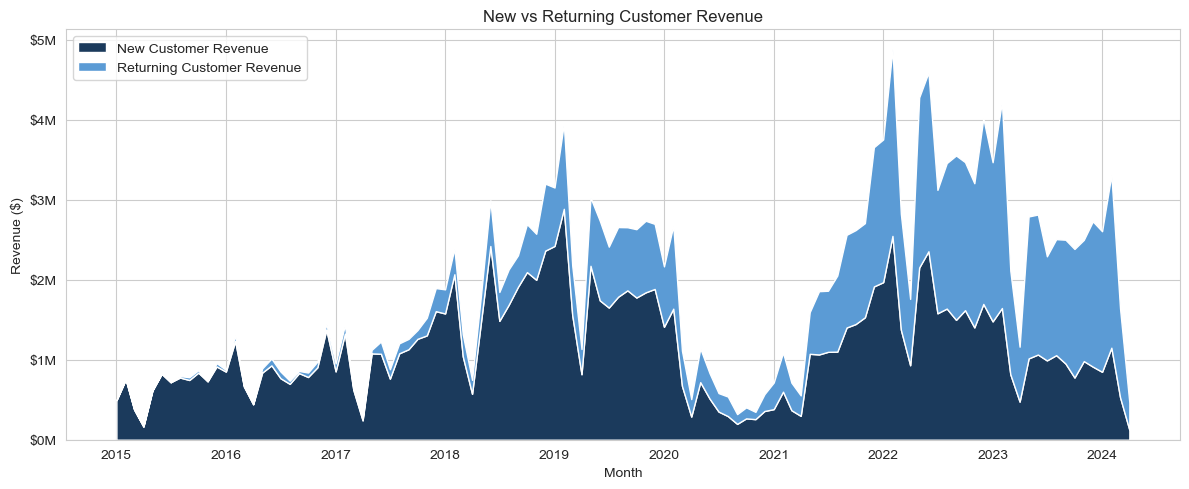

In [17]:
df_nvr = pd.read_sql(NEW_VS_RETURNING, engine)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(df_nvr['month'], df_nvr['new_revenue'], df_nvr['returning_revenue'],
             labels=['New Customer Revenue', 'Returning Customer Revenue'],
             colors=['#1b3a5c', '#5b9bd5'])
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Month')
ax.set_title('New vs Returning Customer Revenue')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x/1e6:.0f}M"))
plt.tight_layout()
plt.savefig('../../images/new_vs_returning_revenue.png', dpi=150)
plt.show()

## 6. Revenue vs gross profit by category

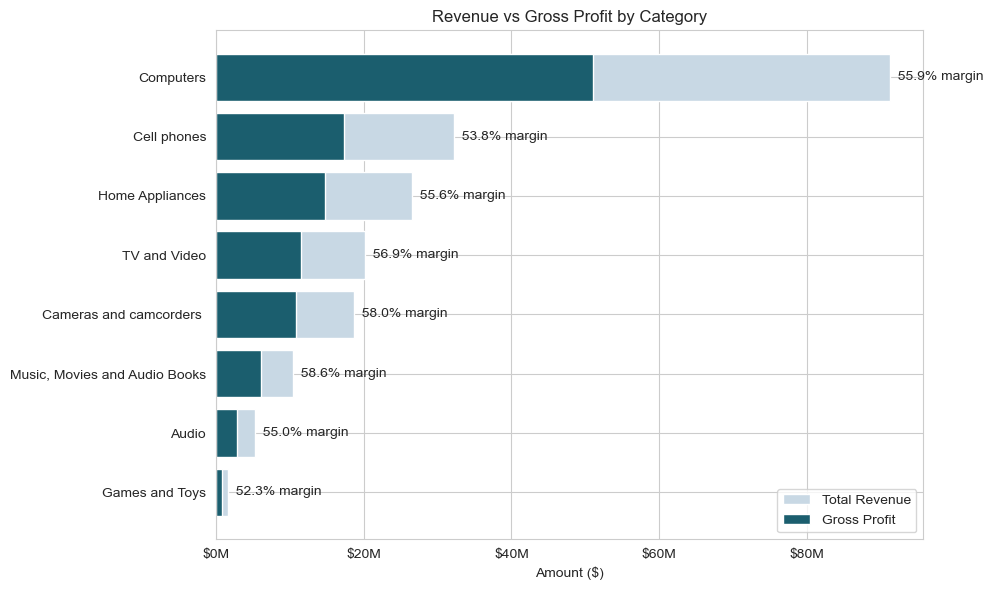

In [ ]:
df_product = pd.read_sql(PRODUCT_ANALYSIS, engine).sort_values('total_revenue')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_product['categoryname'], df_product['total_revenue'], color='#c8d8e4', label='Total Revenue')
ax.barh(df_product['categoryname'], df_product['gross_profit'], color='#1b5e6e', label='Gross Profit')

for i, row in enumerate(df_product.itertuples()):
    ax.text(row.total_revenue, i, f'  {row.avg_margin_pct}% margin', va='center')

ax.set_xlabel('Amount ($)')
ax.set_title('Revenue vs Gross Profit by Category')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x/1e6:.0f}M"))
plt.tight_layout()
plt.savefig('../../images/revenue_vs_gross_profit.png', dpi=150)
plt.show()

## 7. RFM segments, bubble chart & revenue priority

In [2]:
df_rfm = pd.read_sql(RFM_SEGMENTS, engine)

priority_map = {
    'Champions': 'Retain', 'Loyal Customers': 'Retain',
    'At Risk': 'Win-back', "Can't Lose Them": 'Win-back',
    'Potential Loyalists': 'Nurture', 'Needs Attention': 'Nurture', 'New Customers': 'Nurture',
    'Hibernating': 'Low priority', 'Lost': 'Low priority',
}
df_rfm['priority'] = df_rfm['segment'].map(priority_map)

priority_colors = {'Retain': '#2a9d8f', 'Win-back': '#e76f51', 'Nurture': '#f4a261', 'Low priority': '#bdbdbd'}

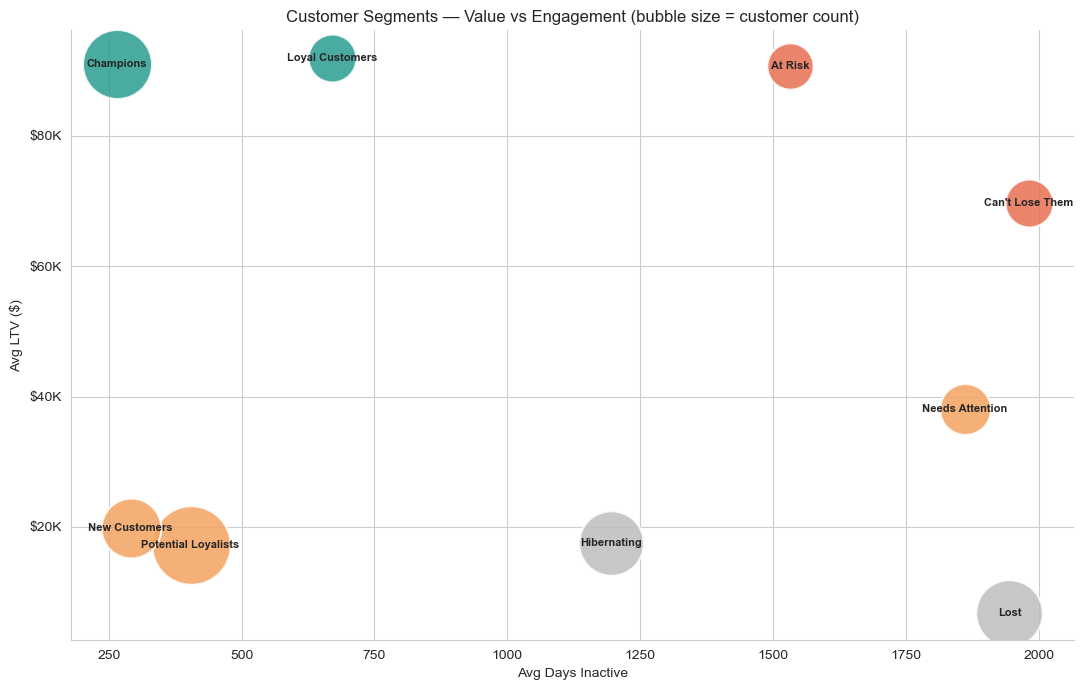

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

size_scale = df_rfm['customer_count'] / df_rfm['customer_count'].max() * 3000 + 200

for _, row in df_rfm.iterrows():
    ax.scatter(row['avg_days_since_purchase'], row['avg_ltv'],
               s=size_scale[row.name], color=priority_colors[row['priority']],
               alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.annotate(row['segment'], (row['avg_days_since_purchase'], row['avg_ltv']),
                ha='center', va='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Avg Days Inactive')
ax.set_ylabel('Avg LTV ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x/100:.0f}K"))
ax.set_title('Customer Segments — Value vs Engagement (bubble size = customer count)')
sns.despine()
plt.tight_layout()
plt.savefig('../../images/rfm_bubble.png', dpi=150)
plt.show()

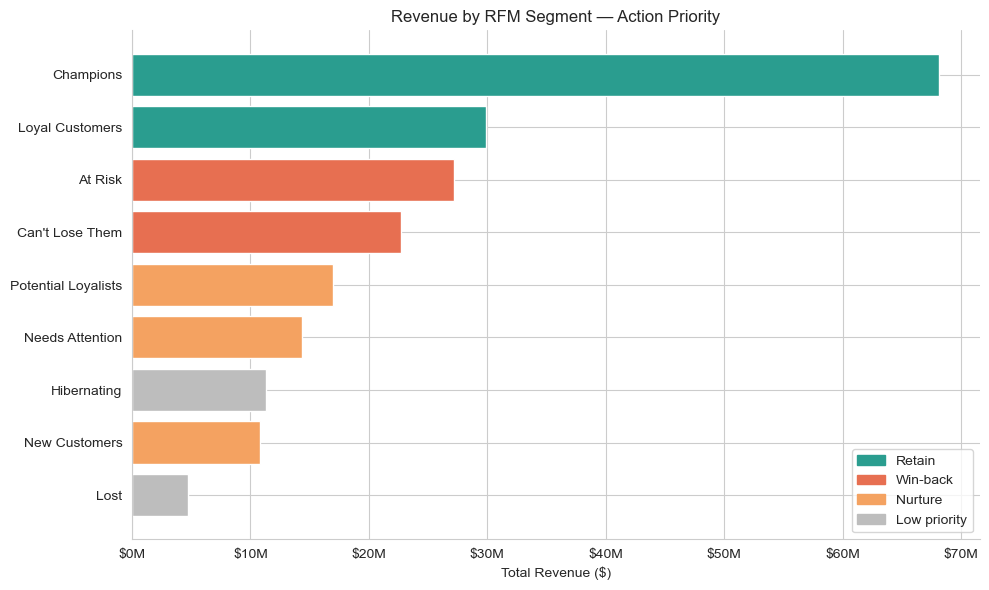

In [8]:
df_rfm_sorted = df_rfm.sort_values('total_revenue')
fig, ax = plt.subplots(figsize=(10, 6))
colors = df_rfm_sorted['priority'].map(priority_colors)
ax.barh(df_rfm_sorted['segment'], df_rfm_sorted['total_revenue'], color=colors)

ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x/1e6:.0f}M"))
ax.set_title('Revenue by RFM Segment — Action Priority')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in priority_colors.values()]
ax.legend(handles, priority_colors.keys(), loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig('../../images/rfm_revenue_priority.png', dpi=150)
plt.show()